In [4]:
import os
from typing import List
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain.vectorstores import FAISS
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END

In [9]:
# -------------------------------
# 1. Prepare Vectorstore
# -------------------------------
docs = TextLoader(r'D:\Python Projects\RAG - Ultimate\FilesForInput\research_notes.txt', encoding="utf-8").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)
embedding = HuggingFaceEmbeddings()
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [10]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="openai/gpt-oss-120b")
llm_groq.invoke("Hey I am Skanda and i like to play cricket")

AIMessage(content='Hey Skanda! 👋 Great to meet a fellow cricket fan.  \n\nDo you play as a batsman, bowler, or an all‑rounder? Which format do you enjoy the most—Test, ODI, T20, or maybe the newer T10 leagues? And are there any teams or players you’re especially cheering for right now? 🎯🏏', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hey I am Skanda and i like to play cricket". The user is just greeting and sharing interest. We can respond friendly. No disallowed content. So respond with greeting, ask about cricket, maybe ask what role they play. Also maybe ask about favorite teams. Keep it friendly.'}, response_metadata={'token_usage': {'completion_tokens': 152, 'prompt_tokens': 82, 'total_tokens': 234, 'completion_time': 0.316885029, 'completion_tokens_details': {'reasoning_tokens': 68}, 'prompt_time': 0.003448131, 'prompt_tokens_details': None, 'queue_time': 0.284204215, 'total_time': 0.32033316}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerpri

In [11]:
# -------------------------------
# 2. LangGraph State Definition
# -------------------------------
class RAGCoTState(BaseModel):
    question: str
    sub_steps: List[str] = []
    retrieved_docs: List[Document] = []
    answer: str = ""

In [12]:
# -------------------------------
# 3. Nodes
# -------------------------------

# a. Plan sub-questions
def plan_steps(state:RAGCoTState) -> RAGCoTState:
    prompt = f"Break the questions into 2-3 reasoning steos: \n \n{state.question}"
    result = llm_groq.invoke(prompt).content
    subqs=[line.strip("- ") for line in result.split("\n") if line.strip()]

    return state.model_copy(update={"sub_steps":subqs})

In [13]:
def retriever_per_step(state:RAGCoTState) -> RAGCoTState:
    all_docs=[]
    for sub in state.sub_steps:
        docs = retriever.invoke(sub)
        all_docs.extend(docs)
    return state.model_copy(update={"retrieved_docs": all_docs})


In [15]:
# c. Generate Final Answer
def generate_answer(state: RAGCoTState) -> RAGCoTState:
    
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
You are answering a complex question using reasoning and retrieved documents.

Question: {state.question}

Relevant Information:
{context}

Now synthesize a well-reasoned final answer.
"""
    result = llm_groq.invoke(prompt).content.strip()
    return state.model_copy(update={"answer": result})

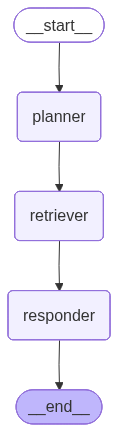

In [17]:
# -------------------------------
# 4. LangGraph Graph
# -------------------------------
builder = StateGraph(RAGCoTState)
builder.add_node("planner", plan_steps)
builder.add_node("retriever", retriever_per_step)
builder.add_node("responder", generate_answer)

builder.set_entry_point("planner")
builder.add_edge("planner", "retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()
graph

In [19]:
# -------------------------------
# 5. Run CoT RAG Agent
# -------------------------------
if __name__ == "__main__":
    query = "what are the Ml and its types?"
    state = RAGCoTState(question=query)
    final = graph.invoke(state)

    print("\n🪜 Reasoning Steps:", final["sub_steps"])
    print("\n✅ Final Answer:\n", final["answer"])


🪜 Reasoning Steps: ['**Step\u202f1 – Define “ML” (Machine\u202fLearning)**', 'Machine\u202fLearning (ML) is a branch of artificial intelligence that enables computers to learn patterns from data and make decisions or predictions without being explicitly programmed for each specific task. The core idea is to build models that improve their performance as they are exposed to more data.', '**Step\u202f2 – Identify the three main families of ML based on how the algorithm learns from data**', '| Family | How it learns | Typical tasks | Example algorithms |', '|--------|---------------|---------------|---------------------|', '| **Supervised Learning** | Learns from labeled examples (input\u202f→\u202fdesired output) | Classification, regression, forecasting | Linear regression, Decision trees, Support Vector Machines, Neural networks |', '| **Unsupervised Learning** | Learns from unlabeled data, discovering hidden structure | Clustering, dimensionality reduction, anomaly detection | K‑mean